# Bank Marketing Response — midterm project

**Question:** How well can lecture-based classifiers identify term-deposit
subscriptions using information available immediately before a scheduled call?
This is binary classification: `y=yes` is the positive class (1).
The primary selection metric is **positive-class F1**, with precision, recall,
ROC-AUC and average precision (AP) as complementary metrics. Success means
outperforming a majority-class baseline on F1, supported by cross-validation.
No arbitrary accuracy target or financial return is promised.

**Stage:** completed computational midterm analysis; 10-slide presentation prepared.
**Team:** Nurlan Ramazan and Araizhan Tazhimova. Actual student contributions
must be recorded after their review. Code and draft explanations were produced
with AI assistance and require team review.
**Evaluation boundary:** this is a historical, approximately stratified,
predictor-profile-grouped random benchmark, not a future-campaign backtest.
The test partition is reserved for the final stage and is never scored here.

In [1]:
from pathlib import Path
import hashlib
import io
import json
import platform
import sys
import time
import urllib.request
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "bank_marketing.py").exists())
RAW = ROOT / "data" / "raw"
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"
for directory in [RAW, RESULTS, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160,
    "font.size": 11, "axes.titlesize": 14,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 14, "figure.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=["#147D92", "#E07A45", "#6254A4", "#6B7280"]),
})
warnings.filterwarnings("error", category=ConvergenceWarning)

def save_figure(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close()

def say(text):
    display(Markdown(text))

print("Python:", platform.python_version(), "| scikit-learn:", sklearn.__version__)
print("Random seed:", SEED)

Python: 3.12.0 | scikit-learn: 1.9.1
Random seed: 42


## 1. Data source, acquisition and meaning

We use **bank-additional-full.csv**, not the older bank-full.csv version.
Source: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing).
License: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
Attribution: Moro, S., Rita, P., & Cortez, P. (2014), Bank Marketing,
UCI Machine Learning Repository, https://doi.org/10.24432/C5K306.
Related paper: Moro, Cortez & Rita (2014), *A Data-Driven Approach to Predict
the Success of Bank Telemarketing*, https://doi.org/10.1016/j.dss.2014.03.001.

These are real historical Portuguese bank campaign records, ordered from
May 2008 to November 2010. A row is an anonymized campaign/contact record,
**not necessarily a unique client**. There is no client identifier or complete
timestamp. The original file has 41,188 rows, 20 inputs and the `y` target.
We include the original source documentation and verify the CSV SHA-256.
No synthetic observations or synthetic oversampling are used.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
DATA_FILE = RAW / "bank-additional-full.csv"
EXPECTED_SHA256 = "74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8"
if not DATA_FILE.exists():
    with urllib.request.urlopen(DATA_URL, timeout=60) as response:
        outer = zipfile.ZipFile(io.BytesIO(response.read()))
    inner = zipfile.ZipFile(io.BytesIO(outer.read("bank-additional.zip")))
    for filename in ["bank-additional-full.csv", "bank-additional-names.txt"]:
        (RAW / filename).write_bytes(inner.read("bank-additional/" + filename))

actual_sha256 = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
assert actual_sha256 == EXPECTED_SHA256, "Source file differs from the documented version."
raw = pd.read_csv(DATA_FILE, sep=";")
assert raw.shape == (41188, 21)
assert set(raw["y"].unique()) == {"yes", "no"}
display(raw.head())
print("Shape:", raw.shape, "| Exact repeated rows:", int(raw.duplicated().sum()))
print("Verified source checksum:", actual_sha256)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Shape: (41188, 21) | Exact repeated rows: 12
Verified source checksum: 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8


In [3]:
descriptions = {
    "age": "Age in years; available before call",
    "job": "Occupation category; available before call",
    "marital": "Marital-status category; available before call",
    "education": "Education category; available before call",
    "default": "Credit-in-default status; includes unknown",
    "housing": "Housing-loan status; includes unknown",
    "loan": "Personal-loan status; includes unknown",
    "contact": "Recorded communication channel; assumed scheduled before call",
    "month": "Call month; assumed known for the scheduled call",
    "day_of_week": "Call weekday; assumed known for the scheduled call",
    "duration": "Realized call length in seconds; EXCLUDED as unavailable before call",
    "campaign": "Campaign contact count including recorded call; use count minus one",
    "pdays": "Days since previous-campaign contact; 999 = no previous contact",
    "previous": "Number of contacts before this campaign",
    "poutcome": "Previous campaign outcome",
    "emp.var.rate": "Quarterly employment variation; assumed available as recorded",
    "cons.price.idx": "Monthly consumer-price index; assumed available as recorded",
    "cons.conf.idx": "Monthly consumer-confidence index; assumed available as recorded",
    "euribor3m": "Daily 3-month Euribor rate; assumed available as recorded",
    "nr.employed": "Quarterly employment indicator; assumed available as recorded",
    "y": "Term deposit subscribed: yes/no; TARGET, never an input",
}
dictionary = pd.DataFrame({
    "feature": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "description": [descriptions[c] for c in raw.columns],
})
dictionary.to_csv(RESULTS / "data_dictionary.csv", index=False)
display(dictionary)

,feature,dtype,description
0,age,int64,Age in years; available before call
1,job,str,Occupation category; available before call
2,marital,str,Marital-status category; available before call
3,education,str,Education category; available before call
4,default,str,Credit-in-default status; includes unknown
5,housing,str,Housing-loan status; includes unknown
6,loan,str,Personal-loan status; includes unknown
7,contact,str,Recorded communication channel; assumed schedu...
8,month,str,Call month; assumed known for the scheduled call
9,day_of_week,str,Call weekday; assumed known for the scheduled ...


## 2. Partition first and prevent overlap

We remove `duration` **before** constructing predictor profiles. The same
remaining predictor vector may appear multiple times, with or without the
same outcome. Identical predictor profiles must stay in one partition and
in one CV fold. We keep repeated records because no record identifier proves
that they are erroneous duplicates. Their frequency still affects results.

Five shuffled `StratifiedGroupKFold` partitions give approximately 60% train,
20% validation and 20% test: folds 0/1 are test/validation; folds 2–4 are train.
Labels are used only for stratification at this step. Subsequent EDA is train
only. No test predictions or test metrics are produced.

Grouping predictor profiles does **not** establish client-level independence:
repeated clients with changed attributes cannot be identified. Random splits
mix historical periods. Therefore this is a historical benchmark, not proof
of prospective or unseen-client performance. Time-aware validation is a
specified next-stage experiment.

In [4]:
X_all = raw.drop(columns=["duration", "y"]).copy()
y_all = raw["y"].map({"no": 0, "yes": 1}).astype(int)
groups_all = pd.util.hash_pandas_object(X_all, index=False).astype(str)
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_id = np.full(len(raw), -1, dtype=int)
for fold, (_, indices) in enumerate(outer_cv.split(X_all, y_all, groups_all)):
    fold_id[indices] = fold
assert (fold_id >= 0).all()
partition = np.where(fold_id == 0, "test", np.where(fold_id == 1, "validation", "train"))
split_manifest = pd.DataFrame({"row_id": raw.index, "split": partition,
                               "predictor_group": groups_all})
split_manifest.to_csv(RESULTS / "split_manifest.csv", index=False)
group_sets = {name: set(groups_all[partition == name])
              for name in ["train", "validation", "test"]}
assert group_sets["train"].isdisjoint(group_sets["validation"])
assert group_sets["train"].isdisjoint(group_sets["test"])
assert group_sets["validation"].isdisjoint(group_sets["test"])

train_idx = np.flatnonzero(partition == "train")
val_idx = np.flatnonzero(partition == "validation")
X_train, y_train = X_all.iloc[train_idx].copy(), y_all.iloc[train_idx].copy()
X_val, y_val = X_all.iloc[val_idx].copy(), y_all.iloc[val_idx].copy()
train_groups = groups_all.iloc[train_idx]
train_raw = raw.iloc[train_idx].copy()
split_summary = split_manifest.groupby("split", sort=False).agg(
    records=("row_id", "size"), predictor_groups=("predictor_group", "nunique"))
split_summary["fraction"] = split_summary["records"] / len(raw)
split_summary.to_csv(RESULTS / "split_summary.csv")
display(split_summary)
print("Repeated predictor rows in full source:", int(X_all.duplicated().sum()))
print("Overlap between predictor groups: zero. Test scoring: disabled by design.")

,records,predictor_groups,fraction
split,,,
test,8237,7835,0.199985
train,24713,23492,0.600005
validation,8238,7840,0.200010


Repeated predictor rows in full source: 2021
Overlap between predictor groups: zero. Test scoring: disabled by design.


## 3. Training-data quality audit and decisions

`unknown` is an explicit category, not a pandas null. We retain it: absence
of information may itself be predictive, and deleting these rows would lose
data. The `pdays=999` sentinel is handled separately below.
Dates are represented only by month and weekday; no full date is invented.
Plausible extreme ages/contact counts are retained; valid values are not
deleted simply for being rare. Ranges are audited on train without choosing
transformations from the test distribution.

In [5]:
categorical_columns = X_train.select_dtypes(include=["object", "str", "string"]).columns.tolist()
quality = pd.DataFrame({
    "dtype": train_raw.dtypes.astype(str),
    "null_count": train_raw.isna().sum(),
    "unique_values": train_raw.nunique(dropna=False),
    "unknown_count": [int(train_raw[c].eq("unknown").sum())
                      if c in categorical_columns else 0 for c in train_raw.columns],
})
quality.to_csv(RESULTS / "training_data_quality.csv")
display(quality)
numeric_summary = train_raw.select_dtypes(include=np.number).describe().T
numeric_summary.to_csv(RESULTS / "training_numeric_summary.csv")
display(numeric_summary)
assert train_raw["age"].between(0, 120).all()
assert (train_raw[["previous", "duration"]] >= 0).all().all()
assert (train_raw["campaign"] >= 1).all()
assert ((train_raw["pdays"] >= 0) & (train_raw["pdays"] <= 999)).all()
assert set(train_raw["month"]) <= set("jan feb mar apr may jun jul aug sep oct nov dec".split())
assert set(train_raw["day_of_week"]) <= set("mon tue wed thu fri".split())
print("Range/category checks passed. No automatic row deletion performed.")

,dtype,null_count,unique_values,unknown_count
age,int64,0,78,0
job,str,0,12,194
marital,str,0,4,42
education,str,0,8,994
default,str,0,3,5180
housing,str,0,3,591
loan,str,0,3,591
contact,str,0,2,0
month,str,0,10,0
day_of_week,str,0,5,0


,count,mean,std,min,25%,50%,75%,max
age,24713.0,40.035326,10.418187,17.000,32.000,38.000,47.000,98.000
duration,24713.0,258.813661,259.435915,0.000,102.000,180.000,321.000,4918.000
campaign,24713.0,2.557075,2.781554,1.000,1.000,2.000,3.000,56.000
pdays,24713.0,962.472949,186.925971,0.000,999.000,999.000,999.000,999.000
previous,24713.0,0.175252,0.497972,0.000,0.000,0.000,0.000,7.000
emp.var.rate,24713.0,0.089216,1.569002,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,24713.0,93.578635,0.578670,92.201,93.075,93.798,93.994,94.767
cons.conf.idx,24713.0,-40.497459,4.621501,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,24713.0,3.628044,1.733513,0.634,1.344,4.857,4.961,5.045
nr.employed,24713.0,5167.245745,72.224900,4963.600,5099.100,5191.000,5228.100,5228.100


Range/category checks passed. No automatic row deletion performed.


## 4. Exploratory data analysis — training partition only

Each plot below has a data-derived interpretation. These are associations,
not causal effects. Group sizes are shown where response rates are compared.

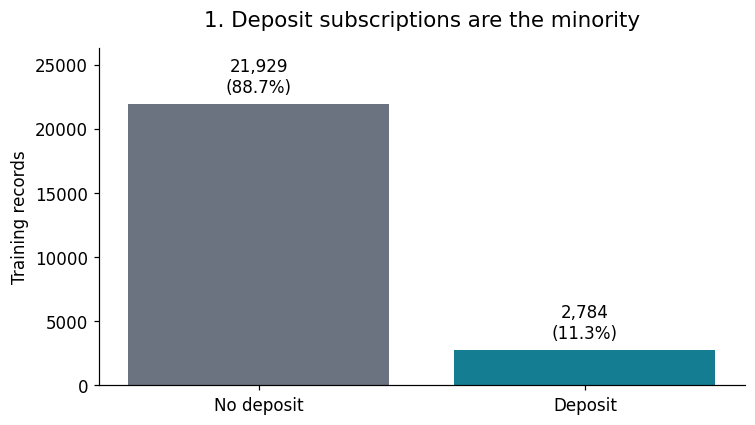

**Interpretation:** 11.27% of training records have y=yes. Always predicting no would achieve 88.73% training accuracy but zero positive recall and F1. Accuracy alone is therefore misleading.

In [6]:
counts = y_train.value_counts().reindex([0, 1])
train_prevalence = float(y_train.mean())
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["No deposit", "Deposit"], counts.values, color=["#6B7280", "#147D92"])
ax.bar_label(bars, labels=[f"{n:,}\n({n/len(y_train):.1%})" for n in counts], padding=5)
ax.set_ylim(0, counts.max() * 1.2)
ax.set(ylabel="Training records", title="1. Deposit subscriptions are the minority")
save_figure("01_target_distribution")
say(f"**Interpretation:** {train_prevalence:.2%} of training records have y=yes. "
    f"Always predicting no would achieve {1-train_prevalence:.2%} training accuracy "
    "but zero positive recall and F1. Accuracy alone is therefore misleading.")

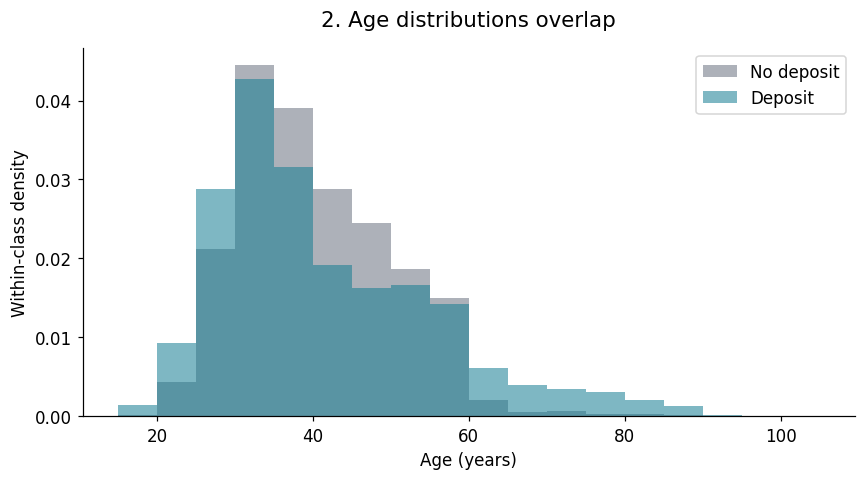

**Interpretation:** Median age is 38 for no and 37 for yes. The plot normalizes each class separately, so the minority class remains visible. Overlap means age alone does not separate outcomes; differences do not establish that age causes subscription.

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, text_label, color in [(0, "No deposit", "#6B7280"), (1, "Deposit", "#147D92")]:
    ax.hist(X_train.loc[y_train == label, "age"], bins=np.arange(15, 106, 5),
            density=True, alpha=.55, label=text_label, color=color)
ax.set(xlabel="Age (years)", ylabel="Within-class density", title="2. Age distributions overlap")
ax.legend()
save_figure("02_age_distribution")
age_medians = X_train.groupby(y_train)["age"].median()
say(f"**Interpretation:** Median age is {age_medians[0]:.0f} for no and "
    f"{age_medians[1]:.0f} for yes. The plot normalizes each class separately, "
    "so the minority class remains visible. Overlap means age alone does not "
    "separate outcomes; differences do not establish that age causes subscription.")

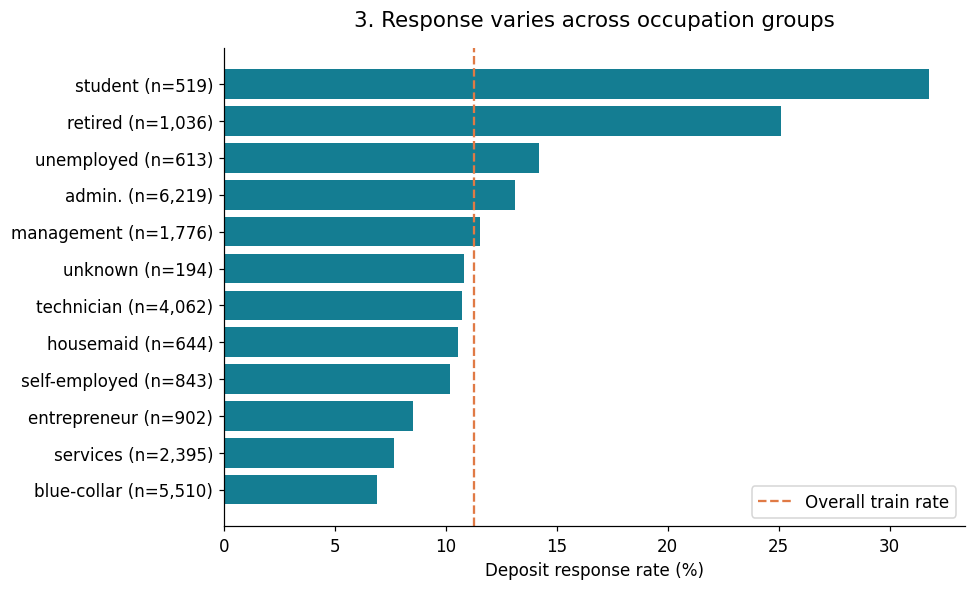

**Interpretation:** student has the highest observed rate (31.8%; n=519), and blue-collar the lowest (6.9%). Group sizes differ. These historical associations can reflect campaign selection and other attributes; they are not evidence for causal targeting rules.

In [8]:
def response_table(column):
    return (X_train.assign(target=y_train).groupby(column)["target"]
            .agg(records="size", subscriptions="sum", response_rate="mean"))

jobs = response_table("job").sort_values("response_rate")
jobs.to_csv(RESULTS / "eda_job_rates.csv")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh([f"{j} (n={int(n):,})" for j, n in zip(jobs.index, jobs["records"])],
        jobs["response_rate"] * 100)
ax.axvline(train_prevalence * 100, color="#E07A45", linestyle="--", label="Overall train rate")
ax.set(xlabel="Deposit response rate (%)", title="3. Response varies across occupation groups")
ax.legend(loc="lower right")
save_figure("03_job_response")
say(f"**Interpretation:** {jobs.index[-1]} has the highest observed rate "
    f"({jobs.iloc[-1]['response_rate']:.1%}; n={int(jobs.iloc[-1]['records']):,}), "
    f"and {jobs.index[0]} the lowest ({jobs.iloc[0]['response_rate']:.1%}). "
    "Group sizes differ. These historical associations can reflect campaign "
    "selection and other attributes; they are not evidence for causal targeting rules.")

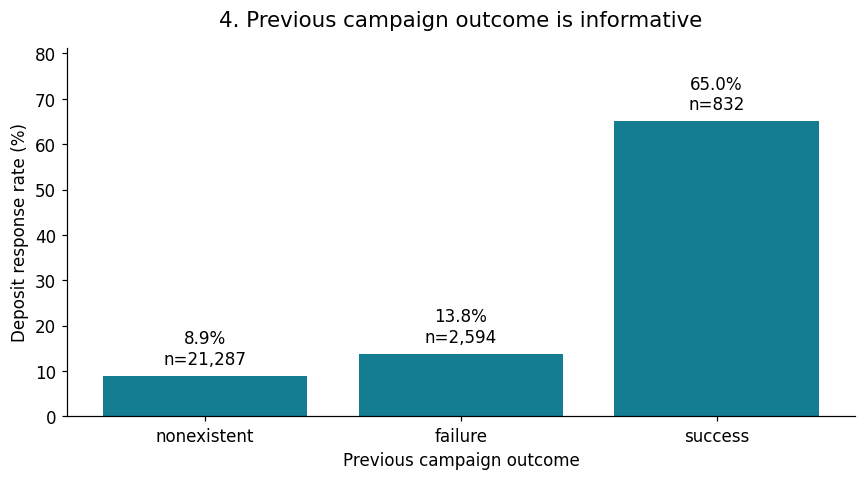

**Interpretation:** The historical-success group has a response rate of 65.0% (n=832). The feature refers to a previous campaign, so it precedes the current outcome. Its association may reflect persistent interest and selection effects.

In [9]:
previous_rates = response_table("poutcome").sort_values("response_rate")
previous_rates.to_csv(RESULTS / "eda_previous_campaign_rates.csv")
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(previous_rates.index, previous_rates["response_rate"] * 100)
ax.bar_label(bars, labels=[f"{r:.1%}\nn={int(n):,}" for r, n in
                           zip(previous_rates["response_rate"], previous_rates["records"])], padding=5)
ax.set_ylim(0, previous_rates["response_rate"].max() * 125)
ax.set(ylabel="Deposit response rate (%)", xlabel="Previous campaign outcome",
       title="4. Previous campaign outcome is informative")
save_figure("04_previous_campaign")
say(f"**Interpretation:** The historical-success group has a response rate of "
    f"{previous_rates.loc['success', 'response_rate']:.1%} "
    f"(n={int(previous_rates.loc['success', 'records']):,}). "
    "The feature refers to a previous campaign, so it precedes the current "
    "outcome. Its association may reflect persistent interest and selection effects.")

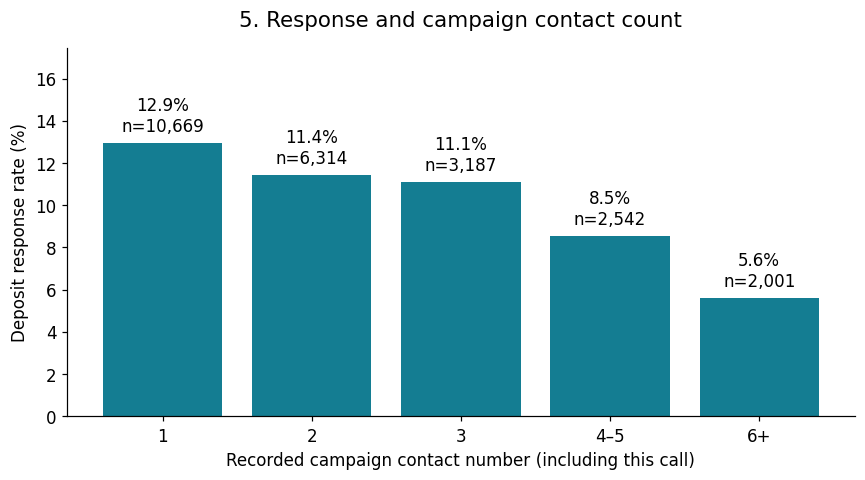

**Interpretation:** The observed response rate is 12.9% for a recorded first contact and 5.6% for 6+ contacts. Repeated attempts may follow earlier non-response; this does not show that an extra call itself reduces willingness to subscribe.

In [10]:
campaign_bands = pd.cut(X_train["campaign"], bins=[0, 1, 2, 3, 5, np.inf],
                        labels=["1", "2", "3", "4–5", "6+"])
campaign_rates = (pd.DataFrame({"band": campaign_bands, "target": y_train})
                  .groupby("band", observed=True)["target"].agg(records="size", response_rate="mean"))
campaign_rates.to_csv(RESULTS / "eda_campaign_rates.csv")
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(campaign_rates.index.astype(str), campaign_rates["response_rate"] * 100)
ax.bar_label(bars, labels=[f"{r:.1%}\nn={int(n):,}" for r, n in
                           zip(campaign_rates["response_rate"], campaign_rates["records"])], padding=5)
ax.set_ylim(0, campaign_rates["response_rate"].max() * 135)
ax.set(xlabel="Recorded campaign contact number (including this call)",
       ylabel="Deposit response rate (%)", title="5. Response and campaign contact count")
save_figure("05_campaign_contacts")
say(f"**Interpretation:** The observed response rate is "
    f"{campaign_rates.iloc[0]['response_rate']:.1%} for a recorded first contact "
    f"and {campaign_rates.iloc[-1]['response_rate']:.1%} for 6+ contacts. "
    "Repeated attempts may follow earlier non-response; this does not show "
    "that an extra call itself reduces willingness to subscribe.")

## 5. Feature engineering and preprocessing

The stateless transformer applies domain rules without learning population
statistics. It creates a previous-contact flag, replaces the pdays sentinel
with missingness, and log-transforms nonnegative contact counts. For campaign
count we subtract the recorded call itself, assuming the count represents
information up to that call. Calendar/channel and economic indicators are
assumed available then; exact publication/revision timing is not provided.
This limits operational claims even after excluding duration.

Unknown categories remain explicit. One-hot encoding avoids an invented
numeric order for occupations or weekdays. Median imputation handles numeric
missingness. Standardization is used for distance/margin models, but not the
tree. The entire preprocessing chain is refit within each CV training fold.

In [11]:
class CampaignFeatures(BaseEstimator, TransformerMixin):
    """Stateless, target-independent transformations of pre-call attributes."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = X.copy()
        # Neither forbidden column can reach the estimator, even if passed by mistake.
        out = out.drop(columns=["duration", "y"], errors="ignore")
        out["previously_contacted"] = (out["pdays"] != 999).astype(int)
        out["days_since_previous_contact"] = out["pdays"].replace(999, np.nan)
        out["log_prior_campaign_contacts"] = np.log1p(out["campaign"] - 1)
        out["log_previous_contacts"] = np.log1p(out["previous"])
        return out.drop(columns=["pdays", "campaign", "previous"])

engineered_train = CampaignFeatures().fit_transform(X_train)
numeric_columns = engineered_train.select_dtypes(include=np.number).columns.tolist()
category_columns = [c for c in engineered_train.columns if c not in numeric_columns]

def make_pipeline(model, scale=True):
    numeric_steps = [("impute", SimpleImputer(strategy="median", keep_empty_features=True))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    preprocess = ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), category_columns),
    ], remainder="drop", verbose_feature_names_out=False)
    return Pipeline([("features", CampaignFeatures()), ("preprocess", preprocess), ("model", model)])

assert "duration" not in engineered_train and "y" not in engineered_train
assert np.isfinite(engineered_train["log_prior_campaign_contacts"]).all()
display(engineered_train.head())
print("Engineered numeric features:", numeric_columns)
print("One-hot encoded features:", category_columns)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,days_since_previous_contact,log_prior_campaign_contacts,log_previous_contacts
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0.0,0.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0.0,0.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0.0,0.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0.0,0.0
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0.0,0.0


Engineered numeric features: ['age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'days_since_previous_contact', 'log_prior_campaign_contacts', 'log_previous_contacts']
One-hot encoded features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 6. Metrics and baseline

Positive F1 balances precision and recall; neither business costs nor a call
budget are supplied. We therefore do not claim an optimal business threshold.
Accuracy is descriptive only. ROC-AUC and AP use continuous scores, not hard
class predictions. AP is **average precision**, not trapezoidal PR-AUC.
Predictions use each estimator's default decision rule; threshold tuning is
deferred to avoid silently optimizing it on validation.

In [12]:
def continuous_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def metric_row(name, model, X, y, split, fit_seconds):
    prediction = model.predict(X)
    score = continuous_score(model, X)
    return {
        "model": name, "split": split, "records": len(y),
        "accuracy": accuracy_score(y, prediction),
        "precision_yes": precision_score(y, prediction, zero_division=0),
        "recall_yes": recall_score(y, prediction, zero_division=0),
        "f1_yes": f1_score(y, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y, score),
        "average_precision": average_precision_score(y, score),
        "fit_seconds": fit_seconds,
    }

started = time.perf_counter()
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_seconds = time.perf_counter() - started
models = {"Dummy (majority)": dummy}
fit_times = {"Dummy (majority)": baseline_seconds}
display(pd.DataFrame([metric_row("Dummy (majority)", dummy, X_val, y_val, "validation", baseline_seconds)]))

,model,split,records,accuracy,precision_yes,recall_yes,f1_yes,roc_auc,average_precision,fit_seconds
0,Dummy (majority),validation,8238,0.887351,0.0,0.0,0.0,0.5,0.112649,0.047182


## 7. Lecture algorithms, five-fold CV and limited tuning

We train **Decision Tree, KNN and a linear SVM**. LinearSVC is a genuine SVM
with a linear boundary; it is not an RBF-kernel SVM. Linear SVM keeps this
initial comparison reproducible on a normal laptop. A nonlinear kernel is
an explicitly deferred experiment.

All models use the same train records and five grouped, approximately
stratified folds. Hyperparameters are selected by mean training-CV F1.
The grid is fixed below before validation comparison. Tree: 12 candidates;
KNN: 6; SVM: 6. Balanced class weights are compared only where supported.
No synthetic resampling or test-set selection is performed.
CV scores used to select hyperparameters have selection optimism; the
untouched validation partition is the separate model-comparison stage.

In [13]:
inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
cv_splits = list(inner_cv.split(X_train, y_train, train_groups))
cv_manifest = []
for fold, (fit_idx, check_idx) in enumerate(cv_splits):
    assert set(train_groups.iloc[fit_idx]).isdisjoint(set(train_groups.iloc[check_idx]))
    assert set(y_train.iloc[fit_idx]) == {0, 1}
    assert set(y_train.iloc[check_idx]) == {0, 1}
    cv_manifest.extend({"row_id": int(X_train.index[i]), "cv_fold": fold,
                        "predictor_group": str(train_groups.iloc[i])} for i in check_idx)
pd.DataFrame(cv_manifest).to_csv(RESULTS / "cv_fold_manifest.csv", index=False)

experiments = {
    "Decision Tree": (
        make_pipeline(DecisionTreeClassifier(random_state=SEED), scale=False),
        {"model__max_depth": [4, 7, 10], "model__min_samples_leaf": [20, 80],
         "model__class_weight": [None, "balanced"]},
    ),
    "KNN": (
        make_pipeline(KNeighborsClassifier(algorithm="brute", n_jobs=1)),
        {"model__n_neighbors": [15, 31, 61], "model__weights": ["uniform", "distance"]},
    ),
    "Linear SVM": (
        make_pipeline(LinearSVC(dual=False, max_iter=20000, random_state=SEED)),
        {"model__C": [0.01, 0.1, 1.0], "model__class_weight": [None, "balanced"]},
    ),
}
scoring = {"f1_yes": "f1", "precision_yes": "precision", "recall_yes": "recall",
           "roc_auc": "roc_auc", "average_precision": "average_precision"}
cv_summary_rows = []
cv_fold_rows = []
best_parameters = {}
for name, (pipeline, parameter_grid) in experiments.items():
    print(f"Training {name}: 5-fold grouped CV...", flush=True)
    started = time.perf_counter()
    search = GridSearchCV(pipeline, parameter_grid, scoring=scoring, refit="f1_yes",
                          cv=cv_splits, n_jobs=1, error_score="raise", return_train_score=False)
    with threadpool_limits(limits=2):
        search.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    models[name] = search.best_estimator_
    fit_times[name] = elapsed
    best_parameters[name] = search.best_params_
    result_frame = pd.DataFrame(search.cv_results_)
    result_frame.to_csv(RESULTS / (name.lower().replace(" ", "_") + "_cv_search.csv"), index=False)
    index = search.best_index_
    row = {"model": name, "candidates": len(result_frame), "folds": 5,
           "search_and_refit_seconds": elapsed}
    for metric in scoring:
        row[f"mean_cv_{metric}"] = float(search.cv_results_[f"mean_test_{metric}"][index])
        row[f"std_cv_{metric}"] = float(search.cv_results_[f"std_test_{metric}"][index])
    cv_summary_rows.append(row)
    for fold in range(5):
        cv_fold_rows.append({"model": name, "fold": fold,
                            **{m: float(search.cv_results_[f"split{fold}_test_{m}"][index]) for m in scoring}})
    print(f"{name}: CV F1={row['mean_cv_f1_yes']:.4f}, elapsed={elapsed:.1f}s", flush=True)
    # Save progress after each completed model.
    pd.DataFrame(cv_summary_rows).to_csv(RESULTS / "cv_summary.csv", index=False)

cv_summary = pd.DataFrame(cv_summary_rows)
pd.DataFrame(cv_fold_rows).to_csv(RESULTS / "cv_selected_folds.csv", index=False)
(RESULTS / "best_parameters.json").write_text(json.dumps(best_parameters, indent=2), encoding="utf-8")
display(cv_summary)
display(pd.DataFrame(best_parameters).T)

Training Decision Tree: 5-fold grouped CV...


Decision Tree: CV F1=0.4456, elapsed=16.1s


Training KNN: 5-fold grouped CV...


KNN: CV F1=0.3537, elapsed=30.5s


Training Linear SVM: 5-fold grouped CV...


Linear SVM: CV F1=0.4479, elapsed=11.3s


,model,candidates,folds,search_and_refit_seconds,mean_cv_f1_yes,std_cv_f1_yes,mean_cv_precision_yes,std_cv_precision_yes,mean_cv_recall_yes,std_cv_recall_yes,mean_cv_roc_auc,std_cv_roc_auc,mean_cv_average_precision,std_cv_average_precision
0,Decision Tree,12,5,16.063602,0.445629,0.022742,0.348363,0.022748,0.618896,0.017600,0.771348,0.015852,0.419014,0.014010
1,KNN,6,5,30.486057,0.353746,0.010045,0.581653,0.019065,0.254676,0.013349,0.746720,0.011048,0.404978,0.015465
2,Linear SVM,6,5,11.284977,0.447925,0.016704,0.350506,0.015144,0.620689,0.020494,0.784377,0.010587,0.432710,0.015641


,model__class_weight,model__max_depth,model__min_samples_leaf,model__n_neighbors,model__weights,model__C
Decision Tree,balanced,10,20,NaN,NaN,NaN
KNN,NaN,NaN,NaN,15,distance,NaN
Linear SVM,balanced,NaN,NaN,NaN,NaN,1.0


## 8. Validation comparison and model selection

Models below are fitted on train only. Validation chooses the candidate
carried into the next stage. Because this choice uses validation scores,
the winning score is not a final unbiased test estimate. Test stays reserved.
Runtime includes each model's entire search and refit, so it is hardware-
dependent and should not be interpreted as single-fit inference cost.

In [14]:
metric_rows = []
prediction_frames = []
with threadpool_limits(limits=2):
    for name, model in models.items():
        metric_rows.append(metric_row(name, model, X_train, y_train, "train", fit_times[name]))
        metric_rows.append(metric_row(name, model, X_val, y_val, "validation", fit_times[name]))
        prediction_frames.append(pd.DataFrame({
            "row_id": X_val.index, "model": name, "y_true": y_val.values,
            "y_pred": model.predict(X_val), "score": continuous_score(model, X_val),
        }))
metrics = pd.DataFrame(metric_rows)
validation_metrics = metrics[metrics["split"] == "validation"].sort_values("f1_yes", ascending=False)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
predictions = pd.concat(prediction_frames, ignore_index=True)
predictions.to_csv(RESULTS / "validation_predictions.csv", index=False)
best_name = validation_metrics.iloc[0]["model"]
best_model = models[best_name]
display(validation_metrics.drop(columns=["split", "records"]).round(4))
say(f"**Selected candidate:** {best_name}, using validation positive-class F1. "
    "No test score was inspected during this decision.")

,model,accuracy,precision_yes,recall_yes,f1_yes,roc_auc,average_precision,fit_seconds
3,Decision Tree,0.8288,0.3527,0.6218,0.4501,0.7837,0.4337,16.0636
7,Linear SVM,0.8252,0.3478,0.6304,0.4483,0.7908,0.4487,11.2850
5,KNN,0.8963,0.5853,0.2737,0.3730,0.7695,0.4140,30.4861
1,Dummy (majority),0.8874,0.0000,0.0000,0.0000,0.5000,0.1126,0.0472


**Selected candidate:** Decision Tree, using validation positive-class F1. No test score was inspected during this decision.

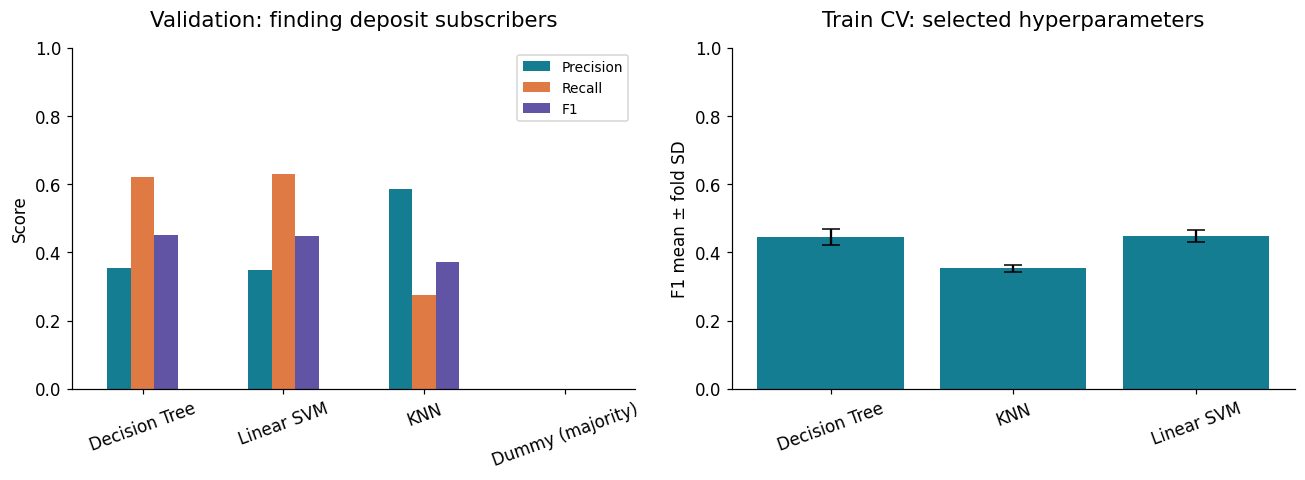

**Interpretation:** Precision and recall reveal the operating trade-off hidden by accuracy. CV error bars are fold standard deviations, not confidence intervals. The reported best-CV scores also reflect hyperparameter selection.

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
display_metrics = validation_metrics.set_index("model")
display_metrics[["precision_yes", "recall_yes", "f1_yes"]].plot.bar(ax=axes[0], rot=20)
axes[0].set(title="Validation: finding deposit subscribers", ylabel="Score", ylim=(0, 1), xlabel="")
axes[0].legend(["Precision", "Recall", "F1"], fontsize=9)
cv_plot = cv_summary.set_index("model")
axes[1].bar(cv_plot.index, cv_plot["mean_cv_f1_yes"],
            yerr=cv_plot["std_cv_f1_yes"], capsize=6)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set(title="Train CV: selected hyperparameters", ylabel="F1 mean ± fold SD", ylim=(0, 1))
save_figure("06_model_comparison")
say("**Interpretation:** Precision and recall reveal the operating trade-off hidden "
    "by accuracy. CV error bars are fold standard deviations, not confidence "
    "intervals. The reported best-CV scores also reflect hyperparameter selection.")

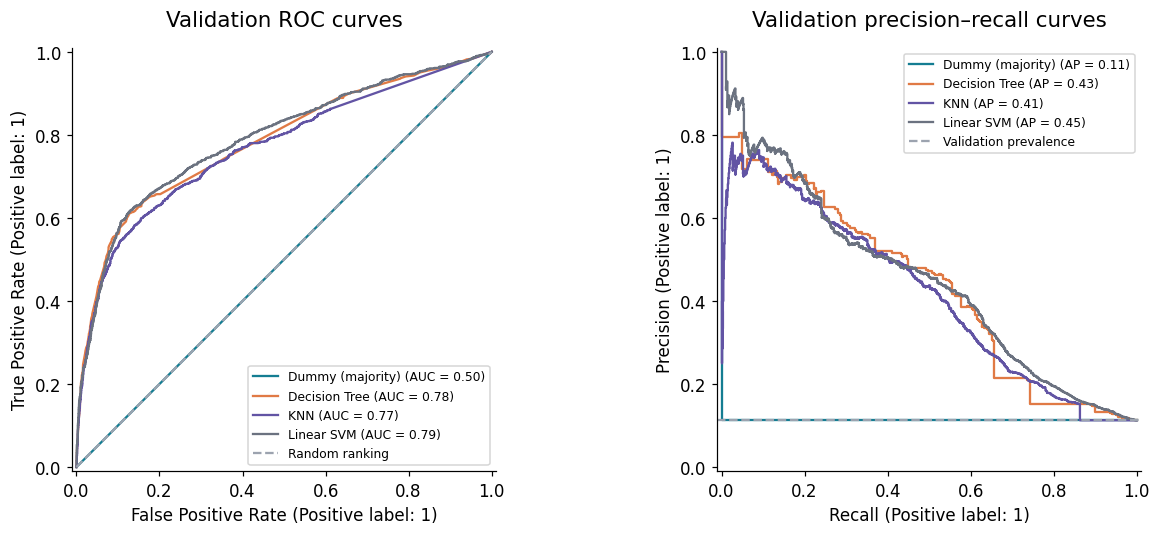

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name in models:
    values = predictions[predictions["model"] == name]
    RocCurveDisplay.from_predictions(values["y_true"], values["score"], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(values["y_true"], values["score"], name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "--", color="#9CA3AF", label="Random ranking")
axes[1].axhline(y_val.mean(), linestyle="--", color="#9CA3AF", label="Validation prevalence")
axes[0].set_title("Validation ROC curves")
axes[1].set_title("Validation precision–recall curves")
for ax in axes:
    ax.legend(fontsize=8, loc="best")
save_figure("07_roc_precision_recall")

## 9. Initial error analysis and interpretation

False positive (FP): predict subscription, observe no subscription — a
potentially unproductive contact. False negative (FN): predict no, observe
subscription — a missed positive case under a targeting policy. These are
observational descriptions, not measured incremental profit or causal lift.

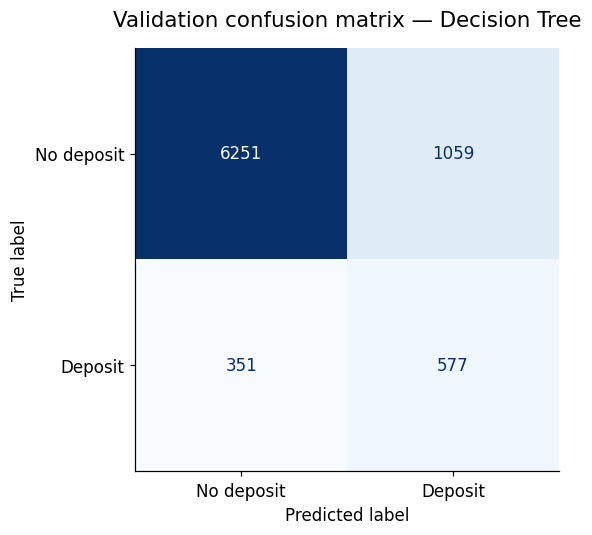

**Interpretation:** TP=577, FP=1,059, FN=351, TN=6,251. The selected model misses 351 actual subscriptions and flags 1,059 non-subscriptions as positive. Improving recall may increase unproductive contacts, so later threshold selection needs an explicit cost or budget.

In [17]:
best_predictions = predictions[predictions["model"] == best_name].copy()
cm = confusion_matrix(best_predictions["y_true"], best_predictions["y_pred"], labels=[0, 1])
tn, fp, fn, tp = [int(v) for v in cm.ravel()]
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No deposit", "Deposit"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Validation confusion matrix — {best_name}")
save_figure("08_confusion_matrix")
say(f"**Interpretation:** TP={tp:,}, FP={fp:,}, FN={fn:,}, TN={tn:,}. "
    f"The selected model misses {fn:,} actual subscriptions and flags {fp:,} "
    "non-subscriptions as positive. Improving recall may increase unproductive "
    "contacts, so later threshold selection needs an explicit cost or budget.")

In [18]:
error_data = X_val.copy()
error_data["y_true"] = y_val
error_data["y_pred"] = best_predictions.set_index("row_id")["y_pred"]
error_data["age_band"] = pd.cut(error_data["age"], bins=[0, 29, 44, 59, 120],
                               labels=["under 30", "30–44", "45–59", "60+"])
subgroup_rows = []
for feature in ["age_band", "job", "poutcome"]:
    for group, subset in error_data.groupby(feature, observed=True):
        positive_n = int(subset["y_true"].sum())
        predicted_n = int(subset["y_pred"].sum())
        subgroup_rows.append({
            "feature": feature, "group": str(group), "records": len(subset),
            "actual_positives": positive_n, "predicted_positives": predicted_n,
            "error_rate": float((subset["y_true"] != subset["y_pred"]).mean()),
            "recall_yes": recall_score(subset["y_true"], subset["y_pred"], zero_division=0) if positive_n else np.nan,
            "precision_yes": precision_score(subset["y_true"], subset["y_pred"], zero_division=0) if predicted_n else np.nan,
        })
subgroup_errors = pd.DataFrame(subgroup_rows)
subgroup_errors.to_csv(RESULTS / "validation_subgroup_errors.csv", index=False)
display(subgroup_errors.round(3))
say("**Interpretation:** Subgroup metrics are descriptive diagnostics on validation. "
    "Rows with few actual positives have unstable recall, and undefined rates "
    "are left missing. These tables do not establish fairness or justify "
    "excluding demographic groups. No model changes are made from this analysis.")

,feature,group,records,actual_positives,predicted_positives,error_rate,recall_yes,precision_yes
0,age_band,under 30,1181,180,426,0.285,0.750,0.317
1,age_band,30–44,4500,445,700,0.148,0.537,0.341
2,age_band,45–59,2329,214,327,0.130,0.556,0.364
3,age_band,60+,228,89,183,0.456,0.944,0.459
4,job,admin.,2130,271,470,0.173,0.686,0.396
5,job,blue-collar,1840,139,202,0.132,0.353,0.243
6,job,entrepreneur,289,22,43,0.163,0.409,0.209
7,job,housemaid,191,15,30,0.152,0.533,0.267
8,job,management,550,66,119,0.198,0.576,0.319
9,job,retired,335,84,162,0.287,0.893,0.463


**Interpretation:** Subgroup metrics are descriptive diagnostics on validation. Rows with few actual positives have unstable recall, and undefined rates are left missing. These tables do not establish fairness or justify excluding demographic groups. No model changes are made from this analysis.

split,train,validation,train_minus_validation_f1
model,,,
Decision Tree,0.4818,0.4501,0.0317
Dummy (majority),0.0000,0.0000,0.0000
KNN,0.9724,0.3730,0.5994
Linear SVM,0.4504,0.4483,0.0021


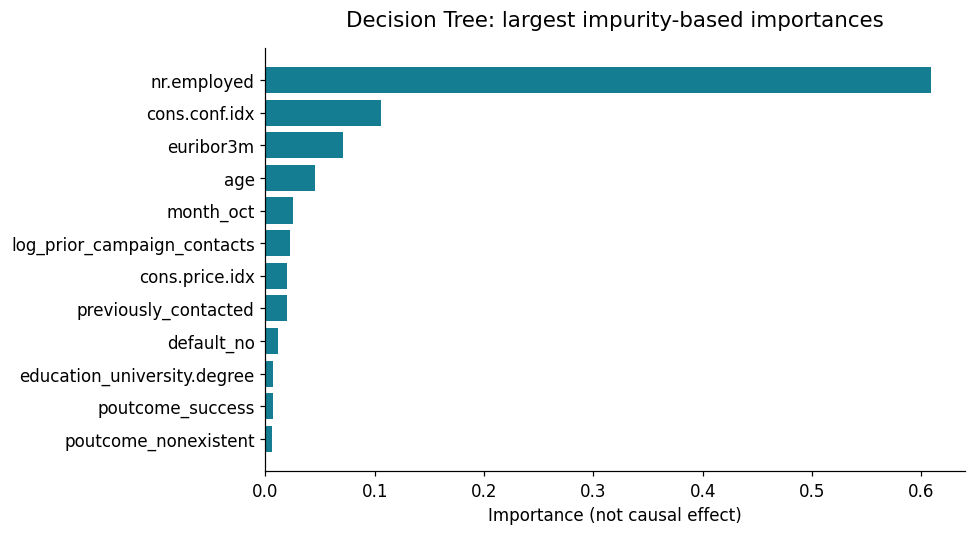

**Interpretation:** A train–validation F1 gap is an overfitting diagnostic. In-sample KNN performance can be especially optimistic because training queries include their own neighbours. Tree importances describe this tree; they can favour certain features and divide importance among correlated economic indicators. They are not causal effects or a universal ranking.

In [19]:
generalization = metrics.pivot(index="model", columns="split", values="f1_yes")
generalization["train_minus_validation_f1"] = generalization["train"] - generalization["validation"]
generalization.to_csv(RESULTS / "generalization_gap.csv")
display(generalization.round(4))
tree_model = models["Decision Tree"]
feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
tree_importance = pd.DataFrame({"feature": feature_names,
                                "importance": tree_model.named_steps["model"].feature_importances_})
tree_importance = tree_importance.sort_values("importance", ascending=False)
tree_importance.to_csv(RESULTS / "tree_feature_importance.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 5))
top = tree_importance.head(12).sort_values("importance")
ax.barh(top["feature"], top["importance"])
ax.set(title="Decision Tree: largest impurity-based importances", xlabel="Importance (not causal effect)")
save_figure("09_tree_importance")
say("**Interpretation:** A train–validation F1 gap is an overfitting diagnostic. "
    "In-sample KNN performance can be especially optimistic because training "
    "queries include their own neighbours. Tree importances describe this tree; "
    "they can favour certain features and divide importance among correlated "
    "economic indicators. They are not causal effects or a universal ranking.")

## 10. Findings, limitations and final-stage plan

This experiment estimates predictive association within a historical sample.
It does not estimate whether contacting a client causes a subscription.
The data are old, from one banking context, and include no complete client
identities, timestamps or feature-publication histories. Unknown categories,
correlated economic variables, repeated observations and minority-class
errors remain relevant limitations. No production deployment is claimed.

Final-stage plan:
1. Implement an ordered-period development evaluation, keeping the reserved
   test rows untouched until all choices are frozen. Decide explicitly whether
   the final claim is historical random-split or prospective evaluation; a true
   prospective test needs a separate chronological design, not a relabelled
   random holdout.
2. Compare a nonlinear SVM and a wider, budgeted hyperparameter search.
3. Select a decision threshold using training out-of-fold predictions and an
   explicit contact budget/cost, then validate once; do not tune on test.
4. Investigate stability and subgroup errors, and consider removing economic
   variables whose publication timing cannot be established.
5. Freeze the specification, refit on train+validation if appropriate, and
   score the existing reserved test exactly as the final historical benchmark.
6. Complete actual student contribution records and rehearse the prepared
   10-slide / 10-minute presentation. Every member must understand and defend the work.

In [20]:
best_row = validation_metrics.iloc[0]
best_cv = cv_summary.set_index("model").loc[best_name] if best_name in experiments else None
summary = {
    "source_rows": len(raw), "source_columns": len(raw.columns),
    "raw_exact_repeated_rows": int(raw.duplicated().sum()),
    "repeated_predictor_rows_without_duration": int(X_all.duplicated().sum()),
    "split_records": {name: int((partition == name).sum()) for name in ["train", "validation", "test"]},
    "train_prevalence": train_prevalence, "validation_prevalence": float(y_val.mean()),
    "best_model": best_name,
    "validation": {key: float(best_row[key]) for key in ["accuracy", "precision_yes", "recall_yes", "f1_yes", "roc_auc", "average_precision"]},
    "selected_model_cv_f1_mean": float(best_cv["mean_cv_f1_yes"]) if best_cv is not None else None,
    "selected_model_cv_f1_std": float(best_cv["std_cv_f1_yes"]) if best_cv is not None else None,
    "confusion_matrix_validation": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "source_sha256": actual_sha256, "random_state": SEED,
    "test_evaluated": False,
    "presentation_created": (ROOT / "presentation" / "bank_marketing_midterm.pptx").is_file(),
    "evaluation_design": "approximately stratified predictor-profile-grouped random 60/20/20 split; 5-fold grouped CV on train",
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
}
(RESULTS / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
assert not summary["test_evaluated"]
assert set(predictions["row_id"]).isdisjoint(set(split_manifest.loc[split_manifest["split"] == "test", "row_id"]))
assert validation_metrics["f1_yes"].max() > validation_metrics.loc[validation_metrics["model"] == "Dummy (majority)", "f1_yes"].iloc[0]
say(f"**Main finding:** {best_name} leads the validation comparison with "
    f"F1={best_row['f1_yes']:.3f}, precision={best_row['precision_yes']:.3f}, "
    f"recall={best_row['recall_yes']:.3f}, ROC-AUC={best_row['roc_auc']:.3f}, "
    f"and AP={best_row['average_precision']:.3f}. It improves on the majority "
    "baseline's positive F1 of zero. This is a validation finding; the test set "
    "remains reserved and no prospective performance claim is made.")
print("Complete: results saved; all overlap and test-isolation assertions passed.")

**Main finding:** Decision Tree leads the validation comparison with F1=0.450, precision=0.353, recall=0.622, ROC-AUC=0.784, and AP=0.434. It improves on the majority baseline's positive F1 of zero. This is a validation finding; the test set remains reserved and no prospective performance claim is made.

Complete: results saved; all overlap and test-isolation assertions passed.


## References and reproducibility

- UCI Bank Marketing: https://archive.ics.uci.edu/dataset/222/bank+marketing
- Dataset DOI: https://doi.org/10.24432/C5K306
- Original feature documentation: `data/raw/bank-additional-names.txt`
- Scikit-learn, avoiding leakage: https://scikit-learn.org/stable/common_pitfalls.html
- Scikit-learn, metrics: https://scikit-learn.org/stable/modules/model_evaluation.html
- Scikit-learn, grouped CV: https://scikit-learn.org/stable/modules/cross_validation.html
- Course brief: *Machine Learning Algorithms: Midterm Course Project*,
  supplied course document, requirements on pages 1–3.

See README for setup, exact dependencies, rubric mapping, contribution status
and commands. Figures and tables are generated by this notebook/script.